# 3_pCMV_expression.R

In [1]:
wd="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/plot"
setwd(wd)

library(Seurat)
library(ggplot2)
library(stringr)
library(patchwork)
library(ggpubr)
library(R.utils)
library(dplyr)
library(tidyr)
library(ggsignif)

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.3 but the current
version is 1.7.4; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


Attaching package: ‘R.utils’


In [2]:
seurat_obj=readRDS(file="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/seurat_obj/Humanxeno_annot.rds")
sample_new=rep(NA, times=length(seurat_obj@meta.data$sample))
sample_new[which(seurat_obj@meta.data$sample == "328_1")]="xHTx_1"
sample_new[which(seurat_obj@meta.data$sample == "443_2")]="xHTx_2"
sample_new[which(seurat_obj@meta.data$sample == "535_2")]="Control"
seurat_obj@meta.data$sample_new=sample_new
seurat_obj=NormalizeData(seurat_obj)

Normalizing layer: counts



In [3]:
select=seurat_obj[,which(seurat_obj@meta.data$sample=="328_1")]
table(select@meta.data$sample)
table(select@meta.data$cell_type)


328_1 
 5568 


                      CM                       EC Endocardial_Lymphatic_EC 
                    2411                      254                       20 
             Fibroblasts          Lymphoids_human                 Myeloids 
                    1835                       65                        2 
          Myeloids_human           Neuronal_cells                 Pericyte 
                     317                      110                      531 
                     SMC 
                      23 

Generated plot: gene_mean_dist_boxplot_pCMV.pdf



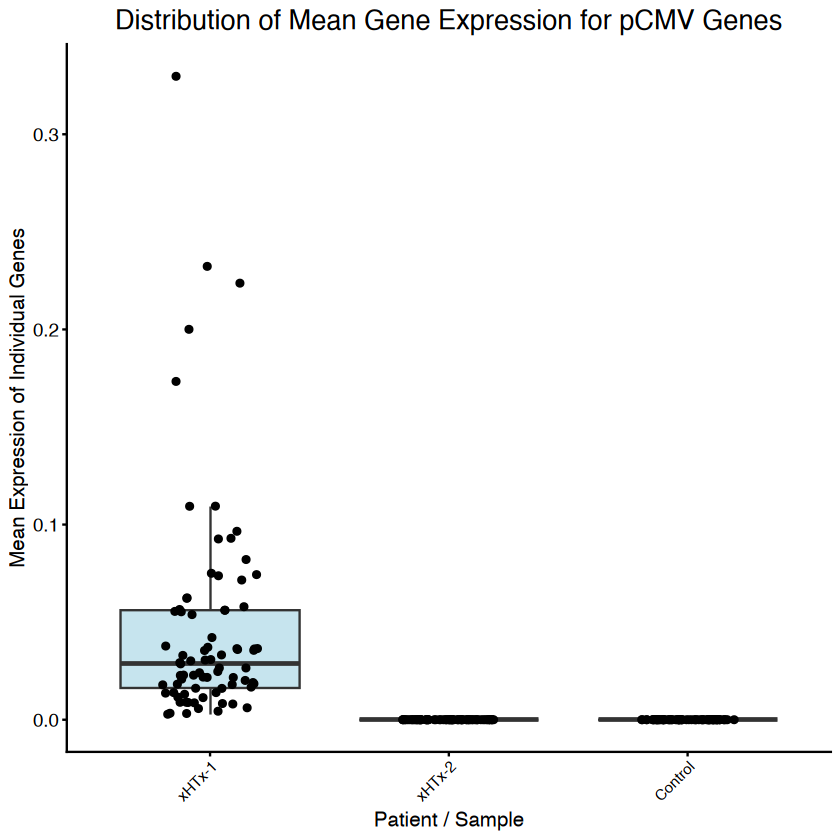

In [7]:
# --- 0. Setup: Your Seurat Object and Gene Lists ---

# Replace this with your actual Seurat object.
# It MUST have a metadata column named 'sample_new' that identifies the individual replicates or patients.


# The marker gene dictionary is translated into a named list in R.
marker_genes_list <- list(
  "pCMV" = c(
    "Sus-scrofa---exon-P379-gp06", "Sus-scrofa---exon-P379-gp07", 
    "Sus-scrofa---exon-P379-gp37", "Sus-scrofa---exon-P379-gp38", 
    "Sus-scrofa---exon-P379-gp60",
    "Sus-scrofa---exon-P379-gp01", "Sus-scrofa---exon-P379-gp02", "Sus-scrofa---exon-P379-gp03",
    "Sus-scrofa---exon-P379-gp04", "Sus-scrofa---exon-P379-gp05", "Sus-scrofa---exon-P379-gp16",
    "Sus-scrofa---exon-P379-gp17", "Sus-scrofa---exon-P379-gp18", "Sus-scrofa---exon-P379-gp19",
    "Sus-scrofa---exon-P379-gp21", "Sus-scrofa---exon-P379-gp22", "Sus-scrofa---exon-P379-gp23",
    "Sus-scrofa---exon-P379-gp24", "Sus-scrofa---exon-P379-gp25", "Sus-scrofa---exon-P379-gp26",
    "Sus-scrofa---exon-P379-gp27", "Sus-scrofa---exon-P379-gp28", "Sus-scrofa---exon-P379-gp29",
    "Sus-scrofa---exon-P379-gp30", "Sus-scrofa---exon-P379-gp31", "Sus-scrofa---exon-P379-gp32",
    "Sus-scrofa---exon-P379-gp33", "Sus-scrofa---exon-P379-gp34", "Sus-scrofa---exon-P379-gp35",
    "Sus-scrofa---exon-P379-gp36", "Sus-scrofa---exon-P379-gp45", "Sus-scrofa---exon-P379-gp46",
    "Sus-scrofa---exon-P379-gp47", "Sus-scrofa---exon-P379-gp48", "Sus-scrofa---exon-P379-gp49",
    "Sus-scrofa---exon-P379-gp50", "Sus-scrofa---exon-P379-gp51", "Sus-scrofa---exon-P379-gp52",
    "Sus-scrofa---exon-P379-gp53", "Sus-scrofa---exon-P379-gp55", "Sus-scrofa---exon-P379-gp56",
    "Sus-scrofa---exon-P379-gp57", "Sus-scrofa---exon-P379-gp58", "Sus-scrofa---exon-P379-gp59",
    "Sus-scrofa---exon-P379-gp65", "Sus-scrofa---exon-P379-gp66", "Sus-scrofa---exon-P379-gp67",
    "Sus-scrofa---exon-P379-gp68", "Sus-scrofa---exon-P379-gp69", "Sus-scrofa---exon-P379-gp70",
    "Sus-scrofa---exon-P379-gp71", "Sus-scrofa---exon-P379-gp72", "Sus-scrofa---exon-P379-gp73",
    "Sus-scrofa---exon-P379-gp74", "Sus-scrofa---exon-P379-gp75", "Sus-scrofa---exon-P379-gp76",
    "Sus-scrofa---exon-P379-gp77", "Sus-scrofa---exon-P379-gp78", "Sus-scrofa---exon-P379-gp79",
    "Sus-scrofa---exon-P379-gp80",
    "Sus-scrofa---exon-P379-gp08", "Sus-scrofa---exon-P379-gp09", "Sus-scrofa---exon-P379-gp10",
    "Sus-scrofa---exon-P379-gp11", "Sus-scrofa---exon-P379-gp12", "Sus-scrofa---exon-P379-gp13",
    "Sus-scrofa---exon-P379-gp14", "Sus-scrofa---exon-P379-gp20", "Sus-scrofa---exon-P379-gp39",
    "Sus-scrofa---exon-P379-gp40", "Sus-scrofa---exon-P379-gp41", "Sus-scrofa---exon-P379-gp42",
    "Sus-scrofa---exon-P379-gp43", "Sus-scrofa---exon-P379-gp44", "Sus-scrofa---exon-P379-gp61",
    "Sus-scrofa---exon-P379-gp62", "Sus-scrofa---exon-P379-gp63", "Sus-scrofa---exon-P379-gp64"
  )
)

# --- 1. Extract and aggregate data from your Seurat Object ---

# Get a single vector of all unique genes to check.
all_genes <- unique(unlist(marker_genes_list))

# Calculate the mean expression of each gene for each sample (pseudobulking).
mean_expression_per_sample <- AverageExpression(
  seurat_obj,
  assays = "RNA",              # Or your preferred assay
  features = all_genes,        # Use all genes from your lists
  group.by = "sample_new"          # Group cells by the 'sample' metadata column
)$RNA %>% as.data.frame()      # Convert to a standard data frame

# --- 2. Loop through each group and create a plot ---

for (group_name in names(marker_genes_list)) {
  
  gene_list <- marker_genes_list[[group_name]]
  
  # Find which genes from the current group are actually in our expression data.
  genes_in_group <- intersect(gene_list, rownames(mean_expression_per_sample))
  
  if (length(genes_in_group) == 0) {
    message(paste("Skipping group '", group_name, "' as no genes were found in the data.", sep=""))
    next
  }

  # Select the data for the current group and reshape for plotting.
  plot_df <- mean_expression_per_sample[genes_in_group, , drop = FALSE] %>%
    tibble::rownames_to_column("Gene") %>%
    pivot_longer(
      cols = -Gene,
      names_to = "Sample",
      values_to = "Mean_Expression"
    )
  
  # --- CRITICAL ADDITION: Set the factor levels for Sample order ---
  # Set the desired order for the x-axis columns
  desired_order <- c("xHTx-1", "xHTx-2", "Control")
  
  # Use mutate to convert 'Sample' to a factor with the specified order.
  # This ensures the plot order is correct.
  plot_df <- plot_df %>%
    mutate(Sample = factor(Sample, levels = desired_order))
  
  # --- 3. Create and save the box plot with requested theme ---
  
  p <- ggplot(plot_df, aes(x = Sample, y = Mean_Expression)) +
    geom_boxplot(fill = "lightblue", alpha = 0.7, outlier.shape = NA) +
    
    # Add a jitter plot to show individual gene points (equivalent to swarmplot).
    geom_jitter(color = "black", size = 1.5, width = 0.2) +
    
    # Add titles and labels.
    labs(
      title = paste("Distribution of Mean Gene Expression for ", group_name, " Genes", sep=""),
      x = "Patient / Sample",
      y = "Mean Expression of Individual Genes"
    ) +
    
    # Use theme_classic() as a base for a clean look
    theme_classic() + 
    
    theme(
      plot.title = element_text(hjust = 0.5, size = 16),
      axis.title = element_text(size = 12),
      axis.text.x = element_text(angle = 45, hjust = 1), # Rotate x-axis labels
      axis.text.y = element_text(size = 11),
      legend.position = "none",
      
      # Explicitly set all background elements to white for a clean figure
      panel.background = element_rect(fill = "white", color = NA), # Plotting area background
      plot.background = element_rect(fill = "white", color = NA),  # Figure background
      panel.grid.major = element_blank(), # Remove major grid lines
      panel.grid.minor = element_blank(), # Remove minor grid lines
      
      # Ensure the axis line is visible
      axis.line = element_line(colour = "black")
    )
  
  # Print the plot to the RStudio plots pane.
  print(p)
  
  # Save the figure as PDF.
  # We are setting the filename to end in .pdf as requested previously.
  filename <- paste0("gene_mean_dist_boxplot_", group_name, ".pdf") 
  ggsave(filename, plot = p, width = 10, height = 7, dpi = 300)
  message(paste("Generated plot:", filename))
}

Generated plot: gene_mean_dist_boxplot_pCMV.pdf



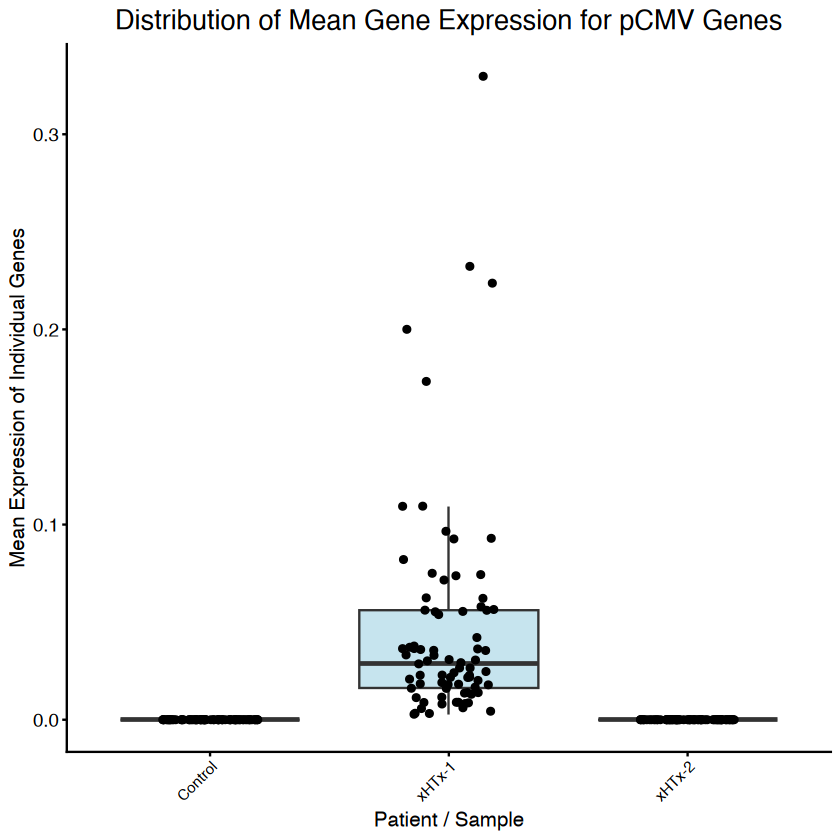

In [9]:
# --- 3. Create and save the box plot ---

# The plot creation is encapsulated in a loop, so we modify the theme block inside.
  p <- ggplot(plot_df, aes(x = Sample, y = Mean_Expression)) +
    geom_boxplot(fill = "lightblue", alpha = 0.7, outlier.shape = NA) +
    
    # Add a jitter plot to show individual gene points (equivalent to swarmplot).
    geom_jitter(color = "black", size = 1.5, width = 0.2) +
    
    # Add titles and labels.
    labs(
      title = paste("Distribution of Mean Gene Expression for ", group_name, " Genes", sep=""),
      x = "Patient / Sample",
      y = "Mean Expression of Individual Genes"
    ) +
    
    # Use theme_classic() as a cleaner starting point, or customize theme_bw()
    theme_classic() + 
    # OR continue with theme_bw() but explicitly set backgrounds to white:
    # theme_bw() + 
    
    theme(
      plot.title = element_text(hjust = 0.5, size = 16),
      axis.title = element_text(size = 12),
      axis.text.x = element_text(angle = 45, hjust = 1), # Rotate x-axis labels
      axis.text.y = element_text(size = 11),
      legend.position = "none",
      
      # Explicitly set all background elements to white
      panel.background = element_rect(fill = "white", color = NA), # Plotting area background
      plot.background = element_rect(fill = "white", color = NA),  # Figure background
      panel.grid.major = element_blank(), # Remove major grid lines
      panel.grid.minor = element_blank(), # Remove minor grid lines
      
      # Keep the axis line black for clarity
      axis.line = element_line(colour = "black")
    )
  
  # Print the plot to the RStudio plots pane.
  print(p)
  
  # Save the figure.
  filename <- paste0("gene_mean_dist_boxplot_", group_name, ".pdf") # Saving as PDF is generally better for vector graphics
  ggsave(filename, plot = p, width = 10, height = 7, dpi = 300)
  message(paste("Generated plot:", filename))

Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


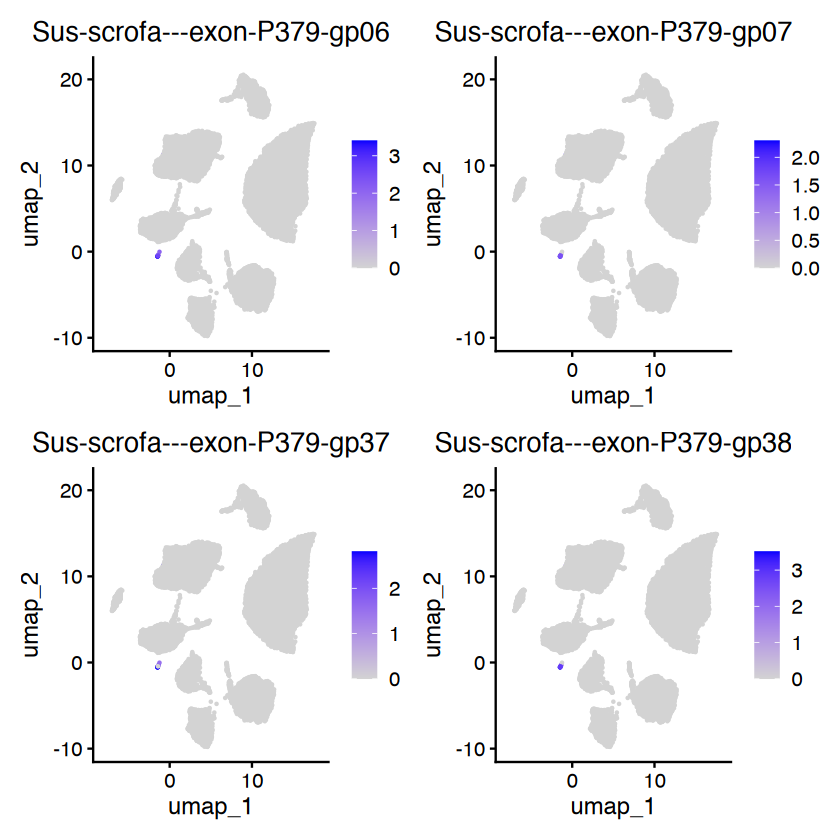

In [27]:
FeaturePlot(seurat_obj, features = c("Sus-scrofa---exon-P379-gp06", "Sus-scrofa---exon-P379-gp07", 
                                     "Sus-scrofa---exon-P379-gp37", "Sus-scrofa---exon-P379-gp38"))

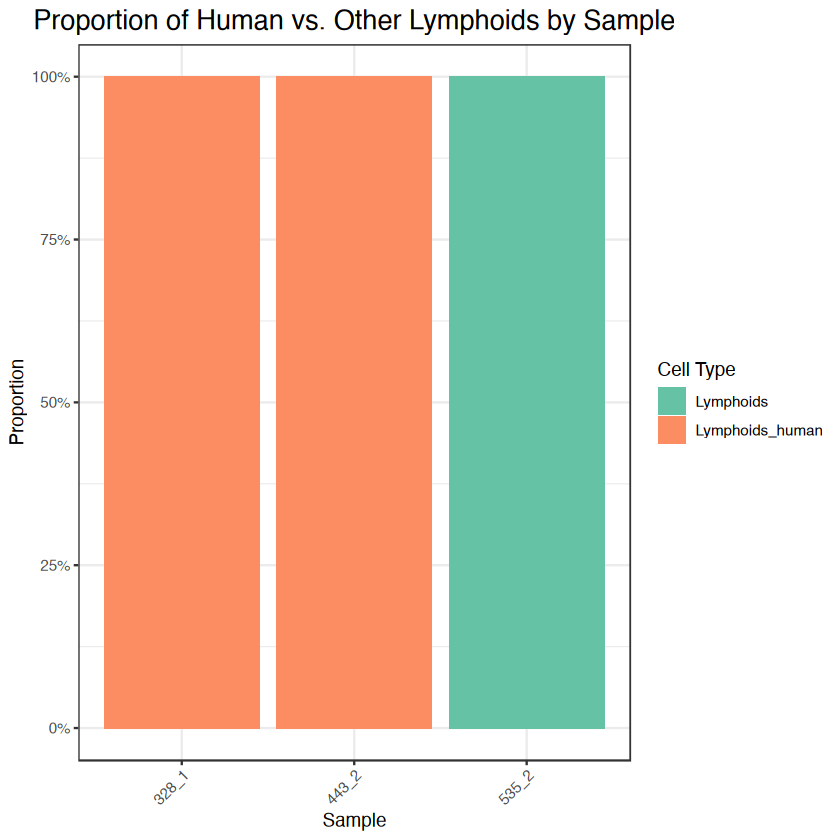

In [39]:
# --- 0. Setup: Your Seurat Object ---
# Replace this with your actual Seurat object.
# It MUST have metadata columns named 'sample' and 'cell_type'.


# --- 1. Prepare Data for Plotting ---

# Calculate the counts and proportions of the two specified cell types per sample.
plot_data <- seurat_obj@meta.data %>%
  # Keep only the rows for the two cell types of interest.
  filter(cell_type %in% c("Lymphoids_human", "Lymphoids")) %>%
  # Group by sample and cell type to count cells.
  group_by(sample, cell_type) %>%
  summarise(count = n(), .groups = 'drop') %>%
  # Group again by just the sample to calculate proportions.
  group_by(sample) %>%
  mutate(
    total_lymphoids = sum(count),
    proportion = count / total_lymphoids
  ) %>%
  ungroup() # Ungroup for cleaner further steps.

# --- 2. Create the Stacked Bar Plot ---

p <- ggplot(plot_data, aes(x = sample, y = proportion, fill = cell_type)) +
  # Create the stacked bars. stat="identity" is crucial as we pre-calculated the y-values.
  geom_bar(stat = "identity", position = "stack") +
  
  # Format the y-axis to show percentages.
  scale_y_continuous(labels = scales::percent_format()) +
  
  # Use a nice color palette.
  scale_fill_brewer(palette = "Set2") +
  
  # Add informative labels and a title.
  labs(
    title = "Proportion of Human vs. Other Lymphoids by Sample",
    x = "Sample",
    y = "Proportion",
    fill = "Cell Type" # Legend title
  ) +
  
  # Use a clean theme and improve readability.
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1), # Rotate sample labels
    plot.title = element_text(hjust = 0.5, size = 16)
  )

# Print the plot to the RStudio plots pane.
print(p)

# Optional: Save the plot to a file.
# ggsave("lymphoid_proportions_stacked_bar.png", plot = p, width = 10, height = 6, dpi = 300)

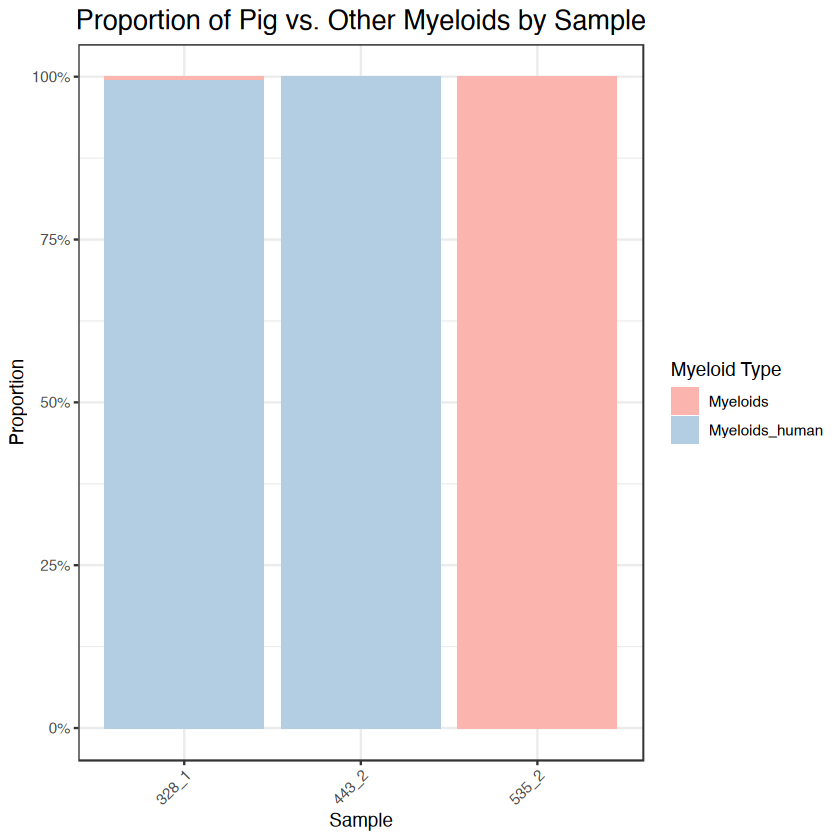

In [42]:
# --- 0. Setup: Your Seurat Object ---
# Use the same Seurat object as before.

# --- 1. Prepare Data for Myeloid Plot ---

# Calculate the counts and proportions of the two myeloid cell types per sample.
myeloid_plot_data <- seurat_obj@meta.data %>%
  # *** CHANGED *** Filter for the myeloid cell types of interest.
  filter(cell_type %in% c("Myeloids", "Myeloids_human")) %>%
  # Group by sample and cell type to count cells.
  group_by(sample, cell_type) %>%
  summarise(count = n(), .groups = 'drop') %>%
  # Group again by just the sample to calculate proportions.
  group_by(sample) %>%
  mutate(
    total_myeloids = sum(count),
    proportion = count / total_myeloids
  ) %>%
  ungroup()

# --- 2. Create the Stacked Bar Plot ---

p_myeloid <- ggplot(myeloid_plot_data, aes(x = sample, y = proportion, fill = cell_type)) +
  # Create the stacked bars.
  geom_bar(stat = "identity", position = "stack") +
  
  # Format the y-axis to show percentages.
  scale_y_continuous(labels = scales::percent_format()) +
  
  # Use a different color palette to distinguish from the lymphoid plot.
  scale_fill_brewer(palette = "Pastel1") +
  
  # Add informative labels and a title.
  labs(
    title = "Proportion of Pig vs. Other Myeloids by Sample",
    x = "Sample",
    y = "Proportion",
    fill = "Myeloid Type" # Legend title
  ) +
  
  # Use a clean theme and improve readability.
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1), # Rotate sample labels
    plot.title = element_text(hjust = 0.5, size = 16)
  )

# Print the plot to the RStudio plots pane.
print(p_myeloid)

# Optional: Save the plot to a file.
# ggsave("myeloid_proportions_stacked_bar.png", plot = p_myeloid, width = 10, height = 6, dpi = 300)